# Dry Bean Dataset: Classifying Bean Varieties
This notebook trains tree-based ensemble classifiers to predict dry bean classes from morphological measurements.


In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from scipy.stats import randint, uniform, loguniform

## Data Inspection
The dataset is loaded from the UCI repository, features and labels are separated, and a train-test split is created.


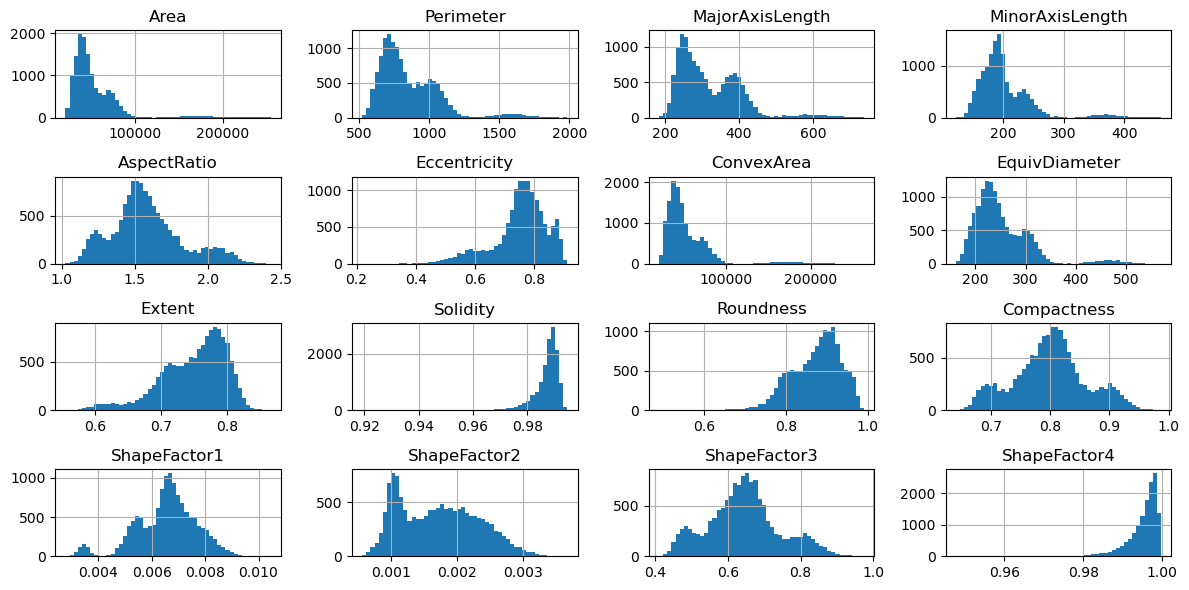

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


In [ ]:
# fetch dataset 
dry_bean = fetch_ucirepo(id=602) 
  
# data (as pandas dataframes) 
X = dry_bean.data.features 
y = dry_bean.data.targets 

X.hist(figsize=(12,6), bins=50)
plt.tight_layout()
plt.show()
X.isnull().sum()
y.isnull().sum()

## Preprocessing
Numerical measurements are standardized before being passed to the classification models.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

num_pipeline = make_pipeline(
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_train.select_dtypes(include=["float64", "int64"]).columns),
])

## Model Selection
Several tree-based ensemble alternatives are searched with randomized cross-validation to identify a strong classifier.


In [4]:
pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", BaggingClassifier())
])

param_distribution = [
    {
        "model": [
            BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                random_state=42,
                n_jobs=-1
                )
            ],
        "model__n_estimators": randint(50, 401),
        "model__estimator__max_depth": [3, 5, 8, 12, 20]

    },
    {
        "model": [RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )],
        "model__n_estimators": randint(50, 401),
        "model__max_depth": [None, 5, 10, 15, 20, 30]

    },
    {
        "model": [GradientBoostingClassifier(
            random_state=42
        )],
        "model__n_estimators": randint(50, 501),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__max_depth": randint(2, 6)
    }
]

rnd = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distribution,
    scoring="f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1,
    n_iter=80
)


rnd.fit(X_train, y_train)

best_model = rnd.best_estimator_

/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:930: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:

## Evaluation
The best model is saved and evaluated on the test set using accuracy, a classification report, and a confusion matrix.


Accuracy: 0.9280205655526992

Classification report:
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.91      0.92       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.94      0.95      0.94       317
    DERMASON       0.91      0.92      0.91       671
       HOROZ       0.98      0.96      0.97       408
       SEKER       0.97      0.94      0.95       413
        SIRA       0.86      0.89      0.88       536

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723

Confusion matrix:



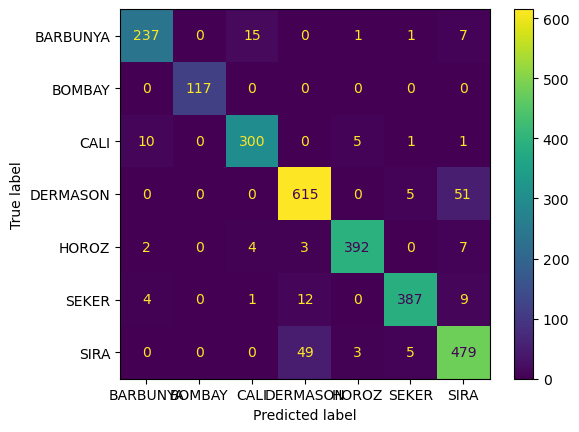

In [8]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print()